# Assignment: Classification of Fashion Items

In this assignment, you will classify fashion articles from the [MNIST fashion dataset](https://github.com/zalandoresearch/fashion-mnist) using two different tools: a k-nearest neighbor classifier and a dense neural network (multilayer perceptron). The relevant material for this assignment is covered in lectures 8 and 9. The assignment instructions are provided on Canvas.

## Boilerplate Notebook Code

Below, you find the boilerplate code that you have to use for the assignment, including basic instructions.
Note that you may need to change the dependency installation procedure.
Debug by removing the `%%capture` line.
If you use a [virtual environment](https://docs.python.org/3/library/venv.html), make sure you can set the notebook's kernel accordingly (assuming your virtual environment is called `venv`):

```
pip3 install ipykernel
python -m ipykernel install --user --name=venv
```

Then, also remove the flags `--user -Iv` below.

In [2]:
%%capture
# Install the dependencies (in case you use Google Colab, these should be available by default, though)
# In case the installation fails or does not yield the desired results remove the `%%capture` line for debugging.
# In case of issues with the import of dependencies, see: https://stackoverflow.com/questions/50914761/jupyter-notebook-cant-find-modules-for-python
! pip install --user -Iv numpy matplotlib pandas scikit-learn

In [3]:
import numpy as np
np.random.seed(42)  # Set the random seed for reproducible results

In [4]:
# Load the Fashion MNIST dataset (this may take a while)

import sklearn.datasets

data = sklearn.datasets.fetch_openml("Fashion-MNIST")

print(data.DESCR)

**Author**: Han Xiao, Kashif Rasul, Roland Vollgraf  
**Source**: [Zalando Research](https://github.com/zalandoresearch/fashion-mnist)  
**Please cite**: Han Xiao and Kashif Rasul and Roland Vollgraf, Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms, arXiv, cs.LG/1708.07747  

Fashion-MNIST is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Fashion-MNIST is intended to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits. 

Raw data available at: https://github.com/zalandoresearch/fashion-mnist

### Target classes
Each training and test example is assigned to one of the following labels:
Label  Description  
0  T-shirt/top  
1  Trouser  
2  Pullover  
3  Dress  
4  

In [5]:
# Split the data into training, (validation), and test set

from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid

Xtrain, Xtest, ytrain, ytest = train_test_split(data.data, data.target, test_size=0.25, random_state=1)

# You may alternatively skip this / have a combined Xtrain and Xval here and instead use cross-validation below
Xtest, Xval, ytest, yval = train_test_split(Xtest, ytest, test_size=0.5, random_state=1)
Xtrain =  np.asarray(Xtrain)
Xtest =  np.asarray(Xtest)
Xval =  np.asarray(Xval)
ytrain =  np.asarray(ytrain)
ytest =  np.asarray(ytest)
yval =  np.asarray(yval)


# Note! Do not touch the test data until the very end!

print(f"Training set size X   : {Xtrain.shape}")
print(f"Training set size y   : {ytrain.shape}")
print(f"Validation set size X : {Xval.shape}")
print(f"Validation set size y : {yval.shape}")
print(f"Test set size X       : {Xtest.shape}")
print(f"Test set size y       : {ytest.shape}")
print(f"Output classes        : {set(ytrain)}")

Training set size X   : (52500, 784)
Training set size y   : (52500,)
Validation set size X : (8750, 784)
Validation set size y : (8750,)
Test set size X       : (8750, 784)
Test set size y       : (8750,)
Output classes        : {'9', '4', '3', '6', '2', '0', '8', '1', '5', '7'}


In [6]:
# Preprocess the data

import sklearn.preprocessing

print(f"Before preprocessing, test data       : "
      f"min = {np.min(Xtrain):.1f}, "
      f"max = {np.max(Xtrain):.1f}, "
      f"mean = {np.mean(Xtrain):.1f}, "
      f"std = {np.std(Xtrain):.1f}")
print(f"Before preprocessing, validation data : "
      f"min = {np.min(Xval):.1f}, "
      f"max = {np.max(Xval):.1f}, "
      f"mean = {np.mean(Xval):.1f}, "
      f"std = {np.std(Xval):.1f}")
print(f"Before preprocessing, test data       : "
      f"min = {np.min(Xtest):.1f}, "
      f"max = {np.max(Xtest):.1f}, "
      f"mean = {np.mean(Xtest):.1f}, "
      f"std = {np.std(Xtest):.1f}")

scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(-1, 1))
scaler.fit(Xtrain)  # Every statistic we compute is found on the training data!

Xtrain = scaler.transform(Xtrain)
Xval = scaler.transform(Xval)
# TODO: If you do cross-validation, you must redo this on the training data in
#       each cross-validation loop, and then transform the validation data as
#       well!
Xtest = scaler.transform(Xtest)

print(f"After preprocessing, test data        : "
      f"min = {np.min(Xtrain):.1f}, "
      f"max = {np.max(Xtrain):.1f}, "
      f"mean = {np.mean(Xtrain):.1f}, "
      f"std = {np.std(Xtrain):.1f}")
print(f"After preprocessing, validation data  : "
      f"min = {np.min(Xval):.1f}, "
      f"max = {np.max(Xval):.1f}, "
      f"mean = {np.mean(Xval):.1f}, "
      f"std = {np.std(Xval):.1f}")
print(f"After preprocessing, test data        : "
      f"min = {np.min(Xtest):.1f}, "
      f"max = {np.max(Xtest):.1f}, "
      f"mean = {np.mean(Xtest):.1f}, "
      f"std = {np.std(Xtest):.1f}")

# TODO: Try to apply other preprocessing, e.g. the
#       sklearn.preprocessing.StandardScaler(), and see if the results improve.

Before preprocessing, test data       : min = 0.0, max = 255.0, mean = 72.9, std = 89.9
Before preprocessing, validation data : min = 0.0, max = 255.0, mean = 73.5, std = 90.3
Before preprocessing, test data       : min = 0.0, max = 255.0, mean = 72.9, std = 90.1
After preprocessing, test data        : min = -1.0, max = 1.0, mean = -0.4, std = 0.7
After preprocessing, validation data  : min = -1.0, max = 1.2, mean = -0.4, std = 0.7
After preprocessing, test data        : min = -1.0, max = 1.7, mean = -0.4, std = 0.7


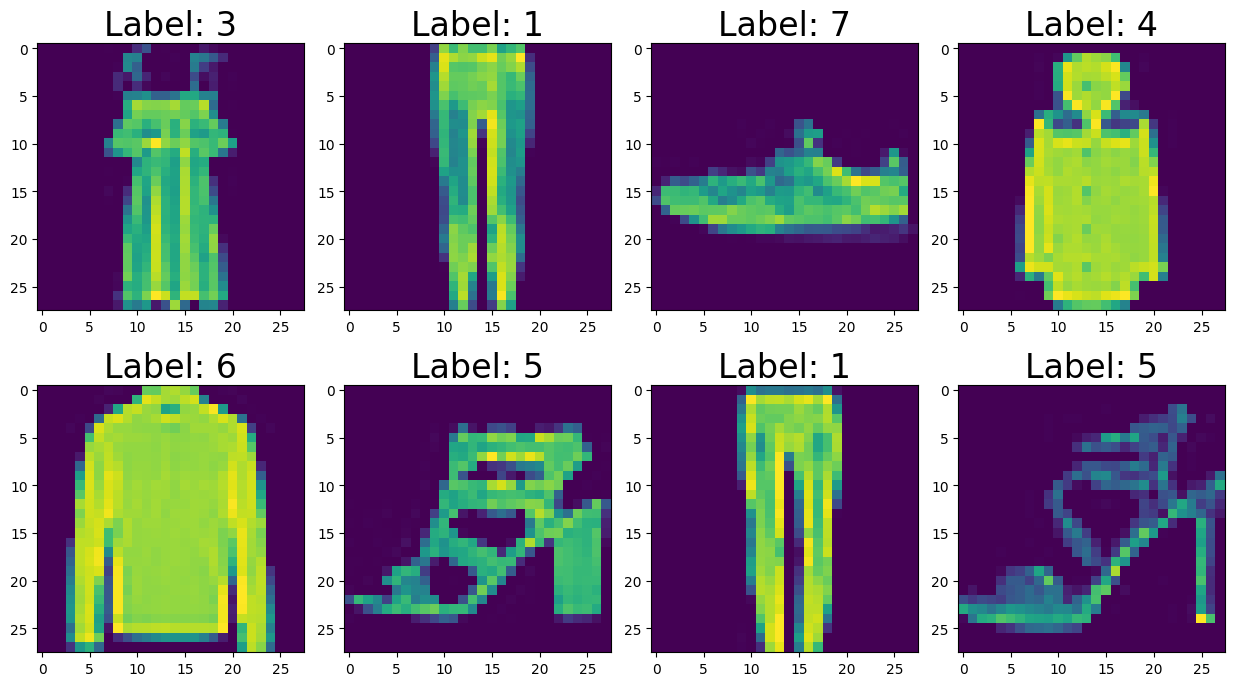

In [7]:
# Plot a few images

import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(12, 7.75))
fig.subplots_adjust(top=0.995,
                    bottom=0.115,
                    left=0.005,
                    right=0.995,
                    wspace=0.15,
                    hspace=0.005)

plot_array = (2, 4)
ax = [[None] * plot_array[1]] * plot_array[0]
it = 0
for i in range(plot_array[0]):
    for j in range(plot_array[1]):
        ax[i][j] = plt.subplot2grid((2, 4), (i, j), rowspan=1, colspan=1)
        ax[i][j].imshow(Xtrain[it, :].reshape((28, 28)))
        ax[i][j].set_title(f"Label: {ytrain[it]}", fontsize=24)
        it += 1

### The $k$-NN model

You have to implement the $k$-NN classifier yourself. The below implementation uses the scikit-learn implementation of the $k$-NN classifier, but you need to do it yourself. Also, perform a hyper-parameter search for the optimal number of neighbors, $k$.

In [5]:
# Create the k-NN classifier
import numpy as np
from collections import Counter

# TODO: Create your own nearest neighbor classifier:
class KNeighborsClassifier:

    def __init__(self, n_neighbors):
        # Note that `self` is the Python-equivalent Java's and JavaScript's `this`,
        # roughly speaking, i.e. it refers to the current instance of your class
        self.n_neighbors = n_neighbors


    def fit(self, X, y):
        # TODO: You need to implement this yourself.
        # Fits the model to your data. For k-NN, this is a mere question of representation.
        self.Xtrain = X
        self.ytrain = y

    def predict(self, testPoint):
        # TODO: You need to implement this yourself.
        distances = []
        for i in range(len(self.Xtrain)):
            dist = self.euclidean_dist(testPoint, self.Xtrain[i])
            distances.append((dist, self.ytrain[i]))
        distances.sort(key=lambda x: x[0])
        k_nearest_labels = [label for _, label in distances[:self.n_neighbors]]
        return Counter(k_nearest_labels).most_common(1)[0][0]


    def euclidean_dist(self, point1, point2):
        return np.sqrt(np.sum((point1 - point2) ** 2))



In [8]:
# Perform grid search to find the number of neighbours, K

k_max = 10  # Set the maximum number of neighbours considered

errs_val = []
# TODO: Perform a hyper-parameter search for the parameter k here. Either use
#       the validation dataset, or optionally use cross-validation here.
k = 1
model = KNeighborsClassifier(n_neighbors=k)
# TODO: The distance computations may take a long time. Play with different
#       amounts of data here to see what is feasible for you. Get it to work
#       on a small amount of data, and then run for a longer time with more
#       data. You may not be able to use all data with the k-NN method,
#       depending on the computer you have for this.
model.fit(Xtrain[:50000, :], ytrain[:50000])
err = model.score(Xval[:10000, :], yval[:10000])
print(f"Number of neighbors: k={k}, validation accuracy: {err}")
errs_val.append(err)

print("Grid search done!")

NameError: name 'KNeighborsClassifier' is not defined

Text(0, 0.5, 'Validation Accuracy')

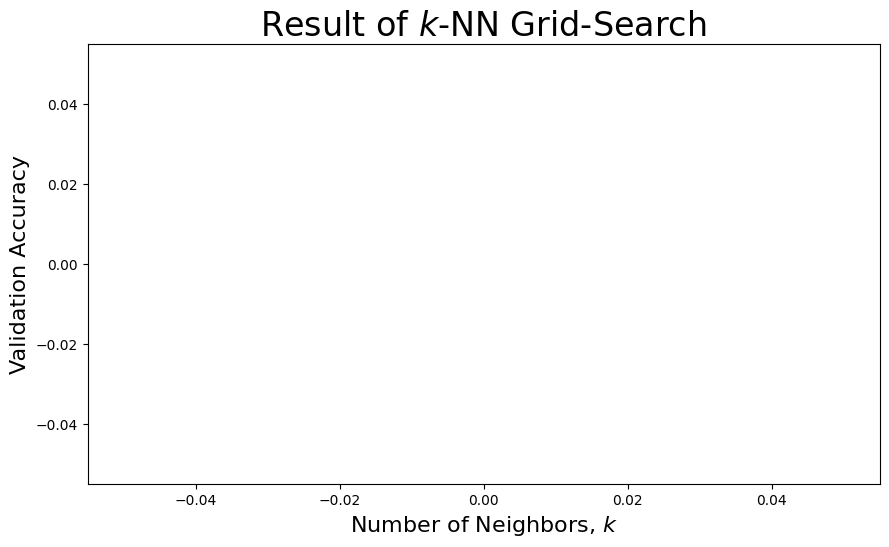

In [9]:
# Plot the accuracy curve as a function of k

fig = plt.figure(figsize=(8, 5))
fig.subplots_adjust(top=0.995,
                    bottom=0.115,
                    left=0.005,
                    right=0.995,
                    wspace=0.15,
                    hspace=0.005)

ax0 = plt.subplot2grid((1, 1), (0, 0), rowspan=1, colspan=1)
ax0.plot(range(1, len(errs_val) + 1), errs_val)
ax0.set_title("Result of $k$-NN Grid-Search", fontsize=24)
ax0.set_xlabel("Number of Neighbors, $k$", fontsize=16)
ax0.set_ylabel("Validation Accuracy", fontsize=16)

In [10]:
# Train the final k-NN model with the best value for k

k_best = np.argmax(errs_val) + 1  # Note that k=1 is at index 0.
print(f"The best value was {errs_val[k_best - 1]}, found using k={k_best}.")

model_knn = KNeighborsClassifier(n_neighbors=k_best)
model_knn.fit(Xtrain[:20000, :], ytrain[:20000])
err = model_knn.score(Xval[:10000, :], yval[:10000])
print(f"Final validation accuracy: {err}")

ValueError: attempt to get argmax of an empty sequence

### The neural network model

We will use the neural networks (multilayer perceptrons) implemented in scikit-learn. You need to find the optimal number of layers, the number of neurons in each of the layers, and any other hyper-parameters that may be relevant. Again, you may first execute the search with a small subset of the data to make sure it works reasonably well.

In [ ]:
# Create the NN classifier

import sklearn.neural_network
from sklearn.model_selection import ParameterGrid

# TODO: Perform grid search to find the number of layers, the number of neurons
#       in each layer, etc.

# TODO: Try different numbers of layers and different numbers of neurons.

param_grid = {
    'hidden_layer_sizes':[
        (32,),
        (64,),
        (128,),
        (32,32),
        (64,64),
        (128,128),
        (32,64),
        (64,128),
        (32,128)
    ],
    'learning_rate_limit': [0.0001, 0.001]
}

# TODO: You may have to test other hyper-parameters than just the number of
#       layers and the number of artificial neurons in each layer. It might be
#       worth varying the learning rate as well, for instance.

errs_val = {}
# instantiate MLP classifier, assigned to `model` variable
# API doc:
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

for params in ParameterGrid(param_grid):
    hidden_layer_sizes = params['hidden_layer_sizes']
    learning_rate = params['learning_rate_limit']

    model = sklearn.neural_network.MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate,
        max_iter=60,
        random_state=30,
    )

    model.fit(Xtrain[:50000], ytrain[:50000])

    err = model.score(Xval[:10000, :], yval[:10000])

    print(f"Hidden layer sizes: {hidden_layer_sizes}, "
    f"learning rate: {learning_rate}, "
    f"validation accuracy: {err}")

    errs_val[(hidden_layer_sizes, learning_rate)] = err

# TODO: The computations may take a long time here as well. Play with
#       different amounts of data to see what's feasible on your
#       computer. Get it to work on a small amount of data first, and
#       then run for a longer time with more data. More data here will
#       improve the results. Using all data may take a long time, but
#       will give good results.

# NOTE: You need to adjust this when you extend your search space and also consider
# hyperparameters like learning rate

print("Grid search done!")

best_params = max(errs_val, key=errs_val.get)

hidden_layer_sizes_best, learning_rate_best = best_params

print(f"The best value was {errs_val[best_params]}, "
      f"found using layer sizes: {hidden_layer_sizes_best}, "
      f"learning rate: {learning_rate_best}.")

model_ann = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes_best,
    alpha=0.0001,
    batch_size='auto',
    learning_rate_init=learning_rate_best,
    max_iter=200,
    random_state=30
)

model_ann.fit(Xtrain[:50000, :], ytrain[:50000])

/Users/victor/PycharmProjects/PythonProject3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/victor/PycharmProjects/PythonProject3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/victor/PycharmProjects/PythonProject3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [ ]:
# Train the final model using the best layer sizes

hidden_layer_sizes_best = max(errs_val, key=errs_val.get, default='')
print(f"The best value was {errs_val[hidden_layer_sizes_best]}, "
      f"found using layer sizes: {hidden_layer_sizes_best}.")

model_ann = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes_best,
    alpha=0.0001,
    batch_size='auto',
    learning_rate_init=0.001,
    max_iter=200,
)

model_ann.fit(Xtrain[:50000, :], ytrain[:50000])
err = model_ann.score(Xval[:10000, :], yval[:10000])

print(f"Final validation accuracy: {err}")

Once we have selected our final model, we can compute the test error on the final models as the last thing we do. Make sure to only do this at the very end, after you have selected the best models you can find.

In [ ]:
# Evaluate the final model on all the data sets, including the test data. We
# only evaluate the test data once, and as the last thing we do. If you train
# another model after this, based on the performance on the test data, then your
# test data is effectively a validation dataset, and you no longer have a test
# dataset. (Or, if you keep your test data set, then your results are biased and
# by that unreliable.)
print(f"k-NN model training data accuracy  : {model_knn.score(Xtrain, ytrain)}")
print(f"k-NN model validation data accuracy: {model_knn.score(Xval, yval)}")
if False:  # Change this to True as the very last thing you do!
    print(f"k-NN model test data accuracy      : "
          f"{model_knn.score(Xtest, ytest)}")

print(f"ANN model training data accuracy   : {model_ann.score(Xtrain, ytrain)}")
print(f"ANN model validation data accuracy : {model_ann.score(Xval, yval)}")
if False:  # Change this to True as the very last thing you do!
    print(f"ANN model test data accuracy       : "
          f"{model_ann.score(Xtest, ytest)}")